# Case Study: Persistent Homology on a Noisy Synthetic Circle

This notebook demonstrates how to generate a synthetic dataset representing a circle with additive Gaussian noise and analyze its topological features using Topological Data Analysis (TDA). We will construct Vietoris-Rips complexes at different filtration thresholds and compute the persistent homology of the dataset.

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
palette = sns.color_palette("bright")

from core.topology import SimplicialComplex
from core.persistence import rips_filtration, PersistenceDiagram

### **The Dataset**

We generate a synthetic dataset of points sampled from a circle $S^1$ of radius $R = 1.0$ with Gaussian noise $\sigma = 0.08$.

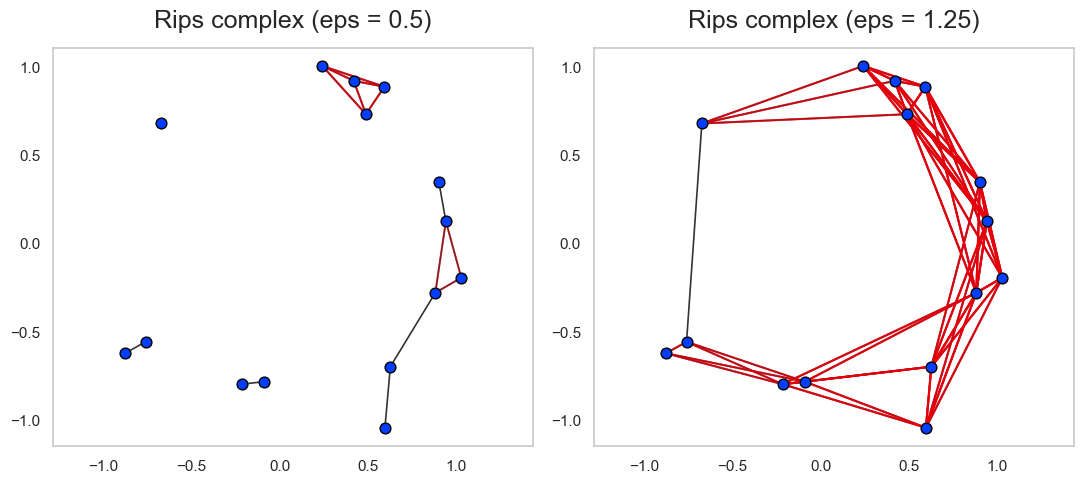

In [28]:
np.random.seed(42)

n_samples = 15
radius = 1.0
noise_level = 0.08

angles = np.random.uniform(0, 2 * np.pi, n_samples)
noise = np.random.normal(0, noise_level, n_samples)
noisy_radius = radius + noise

x = noisy_radius * np.cos(angles)
y = noisy_radius * np.sin(angles)

dataset = np.column_stack((x, y))


fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, eps in zip(axes, [0.5, 1.25]):

    complex = SimplicialComplex()
    rips = complex.rips_complex(dataset, eps)

    edges = rips.by_dim.get(1, [])
    triangles = rips.by_dim.get(2, [])

    ax.set_title(f"Rips complex (eps = {eps})", fontsize=18, pad=15)
    ax.axis('equal')
    ax.grid(False)

    for s in triangles:
        i, j, k = s.vertices
        poly = dataset[[i, j, k, i]]
        ax.plot(poly[:, 0], poly[:, 1],
                color=palette[3], alpha=0.5, zorder=2)

    for s in edges:
        i, j = s.vertices
        ax.plot([dataset[i, 0], dataset[j, 0]],
                [dataset[i, 1], dataset[j, 1]],
                color="black", alpha=0.8, linewidth=1.2, zorder=1)

    ax.scatter(dataset[:, 0], dataset[:, 1],
               color='white', s=55, alpha=1.0, zorder=2.5)

    ax.scatter(dataset[:, 0], dataset[:, 1],
               color=palette[0],
               s=60, edgecolor='black', alpha=1, zorder=3)

plt.tight_layout()
plt.show()

### **Persistent Homology Analysis**

We proceed by constructing a Vietoris-Rips filtration over all filtration thresholds and computing the persistent homology of the dataset using our custom TDA library.

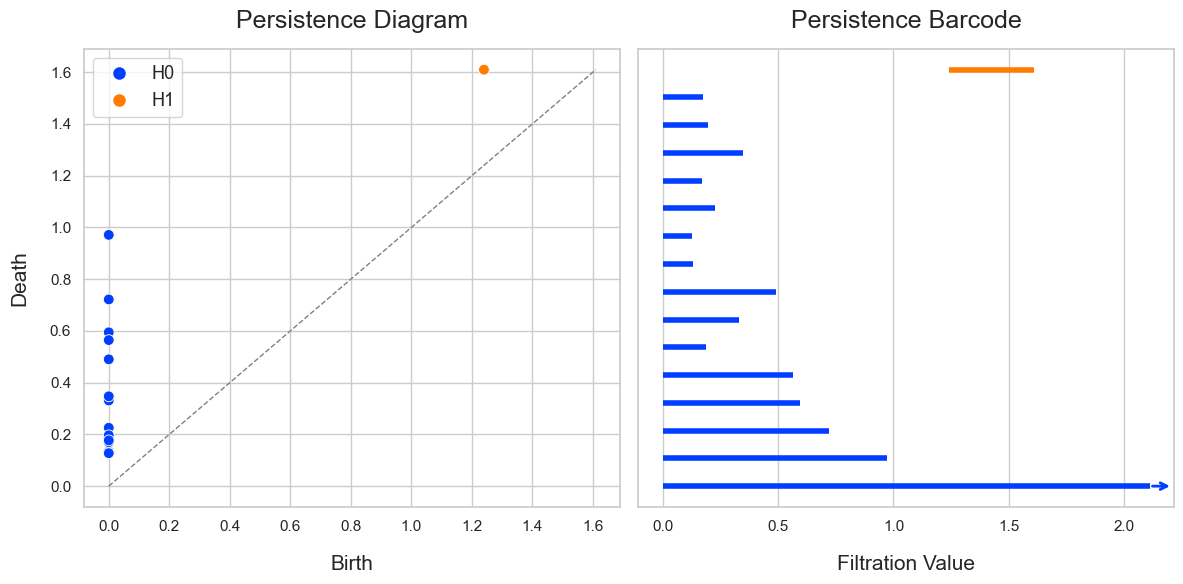

In [30]:
F = rips_filtration(dataset)
pairs = F.extract_pairs()

# Skip identical birth/death times and H2+
clean_pairs = []
for p in pairs:
    if p.birth == p.death:
        continue    
    if p.dim == 2:
        continue
    clean_pairs.append(p)

# print(clean_pairs)

PD = PersistenceDiagram()
for pair in clean_pairs:
    PD.add_pair(pair)

PD.plot_diagram()

### **Validation Against Ripser**

To verify the correctness of our implementation, we compare our persistent homology results with those generated by the standard `ripser` library.

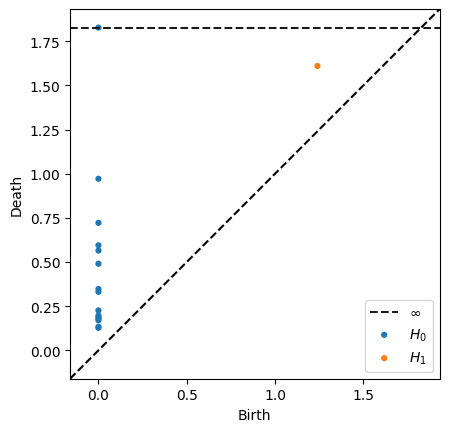

In [32]:
dgms = ripser(dataset)["dgms"]
# print(dgms[0].tolist(), dgms[1].tolist())

plot_diagrams(dgms, show=True)

### **Interpretation of Results**

Our custom TDA implementation successfully extracts the expected topological signatures of a 1-dimensional circle. We observe:
1. A single, highly persistent generator in the first homology group ($H_1$), which corresponds to the circular loop.
2. Multiple short-lived generators in the zero-th homology group ($H_0$), representing the separate components merging into a single connected component.

These findings are validated by comparing them against the standard `ripser` library, showing identical birth and death filtration values.